In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Dataset:

UCI Machine Learning Repository [https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope]

In [26]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConcl", "fAsym","fM3Long","fAlpha","fDist","class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConcl,fAsym,fM3Long,fAlpha,fDist,class
28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [27]:
df["class"].unique()

array(['g', 'h'], dtype=object)

In [40]:
df["class"] = df["class"].astype(str)
df["class"] = df["class"].str.strip()
df["class"] = (df["class"] != "g").astype(int)


In [41]:
df.head()

,fLength,fWidth,fSize,fConc,fConcl,fAsym,fM3Long,fAlpha,fDist,class
28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [30]:
df["class"] = (df["class"] == "g").astype(int) #why do I need to use != to get it 'True' to be represented by 1?
df.head()

,fLength,fWidth,fSize,fConc,fConcl,fAsym,fM3Long,fAlpha,fDist,class
28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,0
31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,0
162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,0
23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,0
75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,0


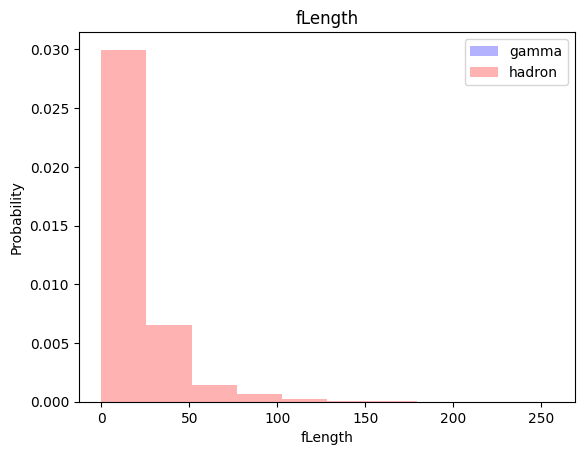

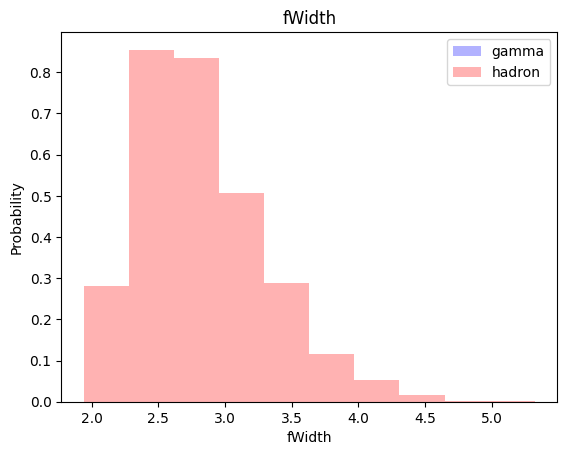

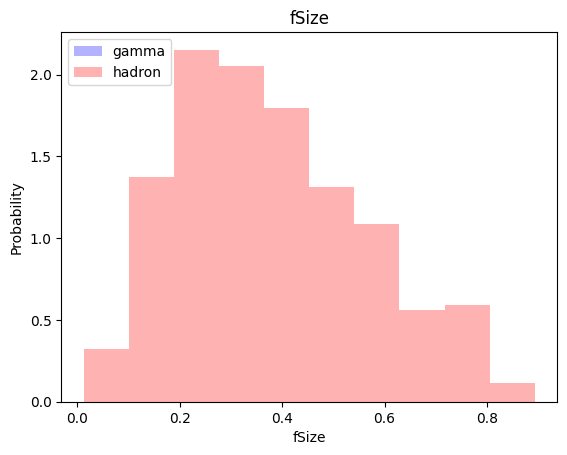

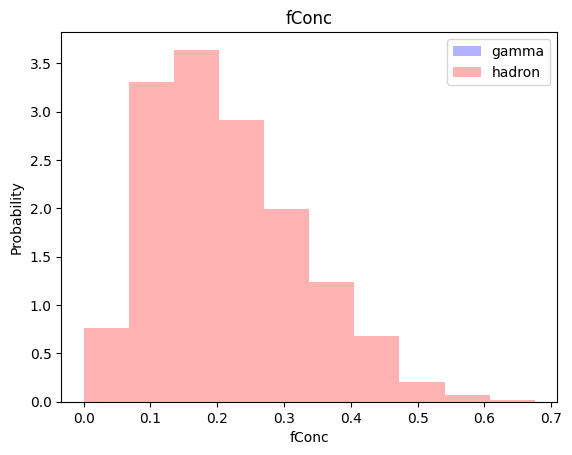

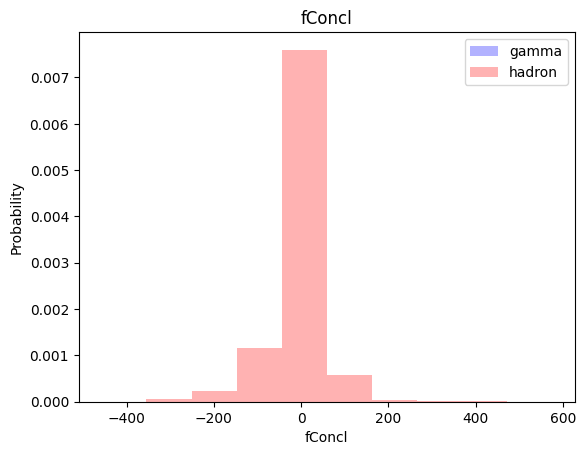

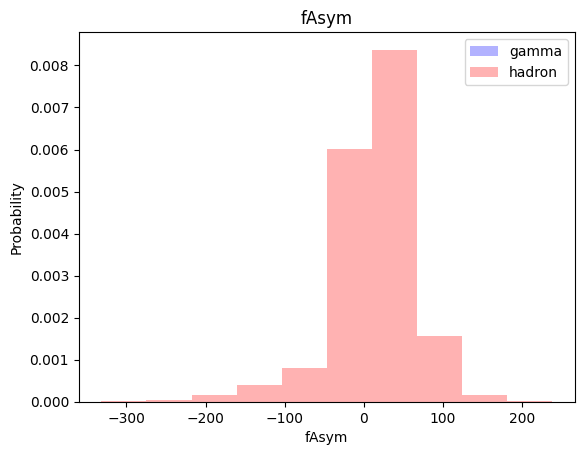

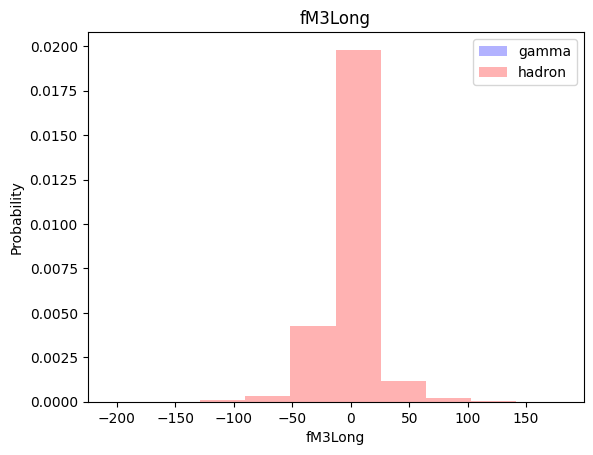

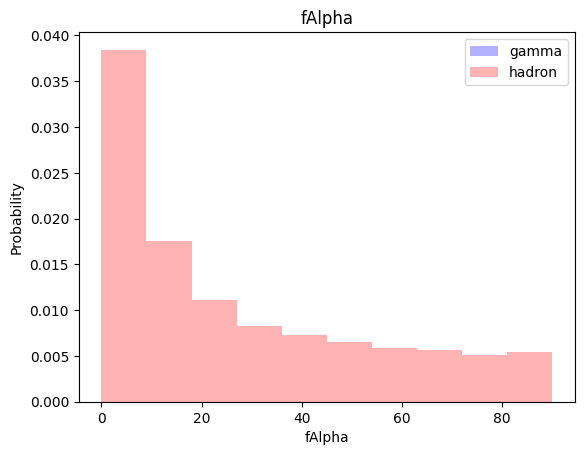

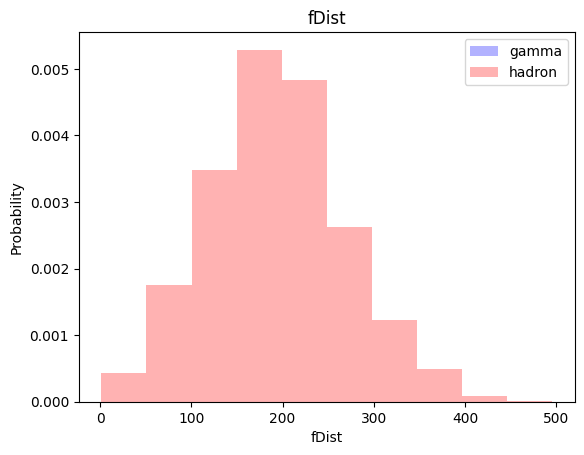

In [43]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==0][label], color="blue", label='gamma', alpha=0.3, density=True) #True normalizes these distributions
    plt.hist(df[df["class"]==1][label], color= "red", label="hadron", alpha=0.3, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend(['gamma','hadron'])
    plt.show()


# Terms

Features - the headings

Supervised Learning because we know what the outcome should be and we know what the inputs are. (the model analyzes the relationship between input and output data...input data X (independent) output data y(dependent variable))

# Given notes:

### What is Machine Learning?

Machine learning is a subdomain of computer science that focuses on algorithms which help a computer learn from data without explicit programming.


### AI vs ML vs DS

#### *Artificial intelligence* 
is an area of computer science, where the goal is to enable computers and machines to perform human-like tasks and simulate human behavior.

##### *Machine Learning* 
is a subset of AI that tries to solve a **specific problem** and **make predictions** using data.

#### Data science

is a field that attempts ot find patterns and draw insights from data (might use ML!) All fields overlap! All may use ML!

In his book Machine Learning for abosolute beginners, Oliver Theobald has a chart where he shows the relationships between these fields.


<img src="../Machine Learning for Everyone/images/relationship-between-data-related-fields.png" width="300">

## Types of Machine Learning

#### Supervised learning
uses labeled inputs (meaning the input has a corresponding output label) to train models and learn outputs.

<img src="../Machine Learning for Everyone/images/SL.png" width = "200">

Think of it as having 'tagged' data. You know what the output should be; you know what the input is. It's like taking apart a lego that has been assembled (you know the output) and then taking a look at all the pieces (input)...

To the computer, all those images are just pixels with different colors...but with the labels...it can...learn...🤷🏾‍♀️

#### Unsupervised learning 
uses unlabeled data to learn about patterns in the data...finding some kind of structure in our unlabeled data. 

<img src="../Machine Learning for Everyone/images/UL.png" width ="200">

Here, say we have lots of images. The computer can classify them based on their similarites, even though it can't give the labels (dogs, cats, lizards).

#### Reinforcement learning
agent learning in interactive environment based on rewards and penalties...

Here, we know the outcome that we want...


## Machine Learning

Imagine a box labeled 'MODEL'; you have any number of inputs and one output (prediction). 

All the inputs are referred to as the 'feature vector'

#### Features
- **Qualitative** - categorical data (finite number of categories or groups... the examples given were gender (male/female) or nationalities)


**Nominal Data** - there is no inherent order...it just...is. If there were a finite number of shoe brands...we may have a list, but nothing inherently comes first.

**One-hot encoding**

We tell the computer to place a 1 when it matches the category.
[Uganda, USA, SA, Australia]

Uganda -> [1,0,0,0]
USA  -> [0,1,0,0]
SA  -> [0,0,1,0]
Australia -> [0,0,0,1]

There's a zero for each category that it doesn't match.

**Ordinal Data**

Imagine that you have these data points : child -> teenager -> adult ->elderly

or ☹️😐🙂😁

This data can be referred to as ORDINAL DATA because...well, there is an inherrent order. child is closer to teenager than elderly. Smiling a little is closer to smiling a lot than outright frowing. 


These types of datasets can be numbered.

Quick Review: 
 **Qualitative** - categorical data (finite number of categories or groups)

- nominal data
- ordinal data

- one hot encoding



**Quantitative** - numerical valued data (could be discrete (integers)or continuous (all real numbers))

Those are our types of inputs.


## Types of predictions

### Supervised Learning Tasks

#### 01 Classification - predict discrete classes

Say we have a hotdog, pizza, and ice cream...those are three classes (multiclass classification),
but there's also **binary classification** (e.g. hot dog, NOT hot dog)
     
| binary classification     | multiclass classification   |
|---------------------------|-----------------------------|
| Positive/negative         |  cat/dog/lizard/dolphin     |
| Cat/dog                   |  orange/apple/pear          |
| Spam/not spam             |  plant species              |

#### 02 - Regression - predict continuous values

Examples: the price of something tomorrow, the temperature...the price of a house.





-----
Now we know a bit of what comes into a model and what comes out of it.

How do we make the model learn? 
How can we tell whether or not it's learning?...How can we tell a good model from a bad model?


**Some terminology**

The row of data is what we would call a 'feature vector' because it has all of our features (the column headings) in one sample. The outcome is known as the 'target' for that feature vector.


The *features matrix* has everything except the final column (X)...and the labels/targets vector is the final column (y)


Each row will be sent to the model and we will compare the predicted output to the actual output...(hence *supervised* learning)...that comparison we do is called 'training the model'


To adequately train the model, we will have the training dataset, the validation dataset, and the testing dataset.

We feed the training dataset into the model...get the 'result vector' compare to the actual results and make the necessary adjustments. Loss is the descripancy. The difference between the prediciton and label.

Validation set used as a reality check during/after training to ensure model can handle unseen data. The test set is used to check how genralizable the final chosen model is.

#### Loss Functions
**L1 Loss** (loss =sum(|y_real - y_predicted)) takes the absolute value of the difference between the real and predicted outcome. (A v on a graph)

**L2 Loss**

/[loss = sum((y_real - y_predicted)^2)/]

This loss is quadratic which means that if its close, the penalty is very minimal but if its off by a lot, the penalty is...much higher.

**Binary Cross-Entropy Loss** 

loss = -1/N*sum(y_real*log(y_predicted)+(1-y_real)*log((1-y_predicted))) ....

...you just need to know that loss decreases as the performance gets better. 😶


#### Other Metrics of Performance

**Accuracy**

| Predictions    | Actual   |
|---------------------------|
| Apple          |  Apple   |
| Orange         |  Orange  |
| Orange         |  Apple   |
| Apple          |  Apple   |

Accuracy of this model is 75% (3/4)